# Analysis Colocation Profiles

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

HERE = Path(os.getcwd())
PATH_DATA = HERE
PATH_RUNS = HERE / 'simulated_data'

In [2]:
# utility functions
sys.path.append(str(HERE.parent.parent / "02_analysis_scripts"))
from utilities import plot_setup, plot_options_default, save_figure, set_min_ticks

# plotting options
_ = plot_setup(plot_options_default)

## Read Data

In [3]:
# path for data
path_results = PATH_DATA / 'metadata.csv'

# save path
output_directory = HERE / "plots" 
save_flag = 1

In [4]:
df_results = pd.read_csv(path_results)
print(df_results.columns)
df_results

Index(['Average Utilization', 'name', 'Power Mean (MW)',
       'Power Peak-to-Avg Ratio', 'Power Std Dev (MW)', 'Power Median (MW)',
       'Power 90th Percentile (MW)', 'Power Max (MW)', 'Utilization Mean',
       'Utilization Std Dev', 'Utilization Median',
       'Utilization 90th Percentile', 'Utilization Max',
       'Performance Avg Daily Jobs', 'Performance Jobs Queued',
       'Performance Mean Queue Time (hours)'],
      dtype='object')


,Average Utilization,name,Power Mean (MW),Power Peak-to-Avg Ratio,Power Std Dev (MW),Power Median (MW),Power 90th Percentile (MW),Power Max (MW),Utilization Mean,Utilization Std Dev,Utilization Median,Utilization 90th Percentile,Utilization Max,Performance Avg Daily Jobs,Performance Jobs Queued,Performance Mean Queue Time (hours)
0,0.2,colocation_10MW_2840nodes_20u_power.csv,2.378843,2.557642,0.847573,2.218280,3.533244,6.084229,0.201435,0.144696,0.173944,0.398592,0.844366,2529,0.000000,NaN
1,0.4,colocation_10MW_2840nodes_40u_power.csv,3.557179,2.063112,1.590799,3.265004,6.397111,7.338859,0.402369,0.271408,0.352817,0.885915,1.000000,5059,0.201529,0.594704
2,0.6,colocation_10MW_2840nodes_60u_power.csv,4.735550,1.543763,1.907486,4.686547,7.080573,7.310565,0.603415,0.325421,0.595070,1.000000,1.000000,7588,0.448563,2.580459
3,0.8,colocation_10MW_2840nodes_80u_power.csv,5.908387,1.238883,1.776169,6.996297,7.121904,7.319798,0.803434,0.302917,0.999296,1.000000,1.000000,10118,0.756437,6.539490


# Plot

In [5]:
# subplots width
total_length = 20
l_week = total_length *6/8
l_day = total_length *2/8

# limits on y-axis
ylim = [0, 10]  # MW

# colors
color = plot_options_default["colors"][1]

plot_options_default["fontsize"] = 18
_ = plot_setup(plot_options_default)

## Plot Hour of the Day

In [6]:
# key: target_utilization -> DataFrame indexed by minute_of_day with percentile columns
d_load_by_util = {}

percentiles = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00]
load_col = "power_W"

for irow, row in df_results.iterrows():
    
    # load timeseries
    path_run = PATH_RUNS / f"{row['name']}"
    series = pd.read_csv(path_run)
    series["timestamp"] = pd.to_datetime(series["timestamp"])
    series = series.set_index("timestamp")

    # Build minute-of-day index
    series["minute_of_day"] = series.index.hour * 60 + series.index.minute

    # Compute percentiles by time of day
    grouped = series.groupby("minute_of_day")[load_col]
    df_pct = grouped.quantile(percentiles).unstack(level=1)

    # Rename percentile columns
    df_pct.columns = [f"p{int(p*100)}" for p in percentiles]

    # Store by utilization
    d_load_by_util[row["Average Utilization"]] = df_pct

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/03_whole-facility_profiles/colocation/plots/2026-03-30_power-day.png


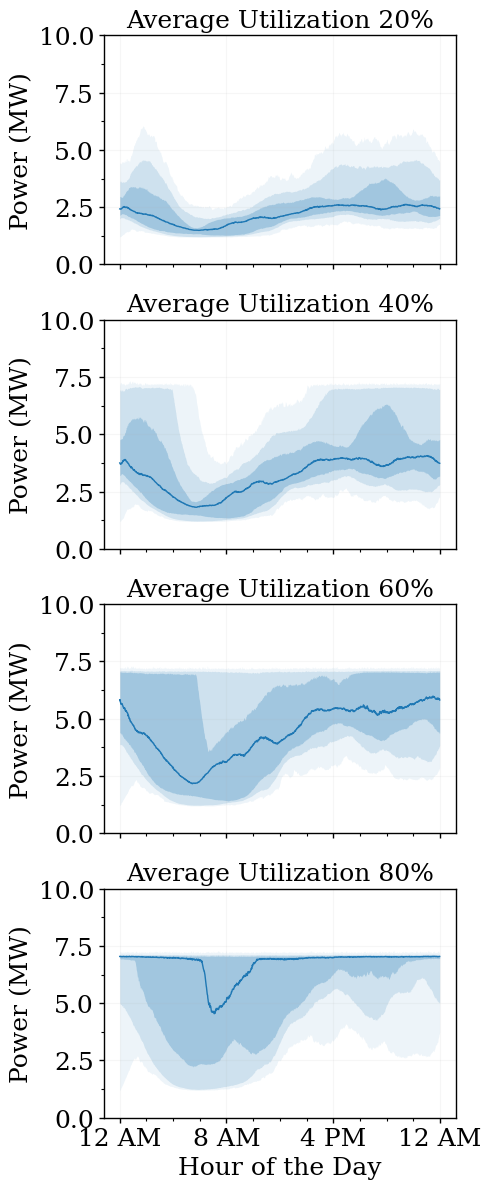

In [7]:
# Plot settings
util_levels = sorted(d_load_by_util.keys())

fig, axes = plt.subplots(
    len(util_levels),
    1,
    sharex=True,
    sharey=True,
    figsize=(l_day, 3 * len(util_levels))
)

# Define bands (lower, upper, alpha, label)
bands = [
    ("p25", "p75", 0.25, "25-75%"),
    ("p10", "p90", 0.15, "10-90%"),
    ("p0", "p100", 0.08, "0-100%"),
]

for ax, util in zip(axes, util_levels):
    df_pct = d_load_by_util[util].copy()
    x = df_pct.index

    # Shade percentile bands
    for low, high, alpha, _label in bands:
        ax.fill_between(
            x,
            df_pct[low] * 1e-6,
            df_pct[high] * 1e-6,
            alpha=alpha,
            linewidth=0,
            color=color
        )

    # Plot median
    ax.plot(x, df_pct["p50"] * 1e-6, linewidth=1,color=color)
    
    # set title
    ax.set_title(f"Average Utilization {util*100:.0f}%")
    ax.set_ylabel("Power (MW)")
    ax.grid(alpha=0.10)
    _ = ax.set_ylim(ylim)
    ax = set_min_ticks(ax, "y", which="major", num_ticks=4)
    ax = set_min_ticks(ax, "y", which="minor", num_ticks=2)
    
# Common legend handles (line + patches)
line_handle = mlines.Line2D([], [], color=color, linewidth=1, label="50%")
line_handle_minmax = mlines.Line2D([], [], color=color, linewidth=1, linestyle="--", label="min-max")
patch_handles = [
    mpatches.Patch(color=color, alpha=alpha, label=label)
    for _, _, alpha, label in bands
]
handles = [line_handle] + patch_handles

# X-axis ticks: minutes to hours (12-hour labels)
axes[-1].set_xlabel("Hour of the Day")
axes[-1].set_xticks(60 * np.array([0, 8, 16, 24]))
axes[-1].set_xticklabels(["12 AM", "8 AM", "4 PM", "12 AM"])

for ax in axes:
    _ = set_min_ticks(ax, "x", which="minor", num_ticks=4)

fig.tight_layout()

# save figure
save_figure(
    fig,
    "power-day",
    save_flag,
    1,
    ["png"],     # ["png", "svg", "pdf"]
    full_path=PATH_DATA / "plots"
)

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/03_whole-facility_profiles/colocation/plots/2026-03-30_power-day-legend.png


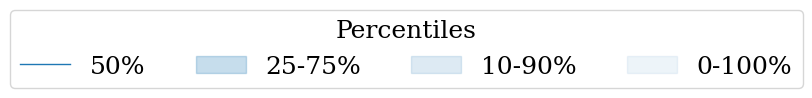

In [8]:
# plot legend
fig_leg, ax_leg = plt.subplots(figsize=(5, 1.0))
ax_leg.legend(
    handles=handles,
    loc="center",
    ncol=len(handles),
    title="Percentiles"
)
ax_leg.axis("off")
fig_leg.tight_layout()

save_figure(
    fig_leg,
    "power-day-legend",
    save_flag,
    1,
    ["png"],     # ["png", "svg", "pdf"]
    full_path=PATH_DATA / "plots"
)

## Plot Time of the Week

In [9]:
for irow, row in df_results.iterrows():
    
    # load timeseries
    path_run = PATH_RUNS / f"{row['name']}"
    series = pd.read_csv(path_run)
    series["timestamp"] = pd.to_datetime(series["timestamp"])
    series = series.set_index("timestamp")

    # Build minute-of-week index
    series["minute_of_week"] = (series.index.dayofweek % 7)*24*60 +    series.index.hour * 60 + series.index.minute    

    # Compute percentiles by time of day
    grouped = series.groupby("minute_of_week")[load_col]
    df_pct = grouped.quantile(percentiles).unstack(level=1)

    # Rename percentile columns
    df_pct.columns = [f"p{int(p*100)}" for p in percentiles]

    # Store by utilization
    d_load_by_util[row["Average Utilization"]] = df_pct

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/03_whole-facility_profiles/colocation/plots/2026-03-30_power-week.png


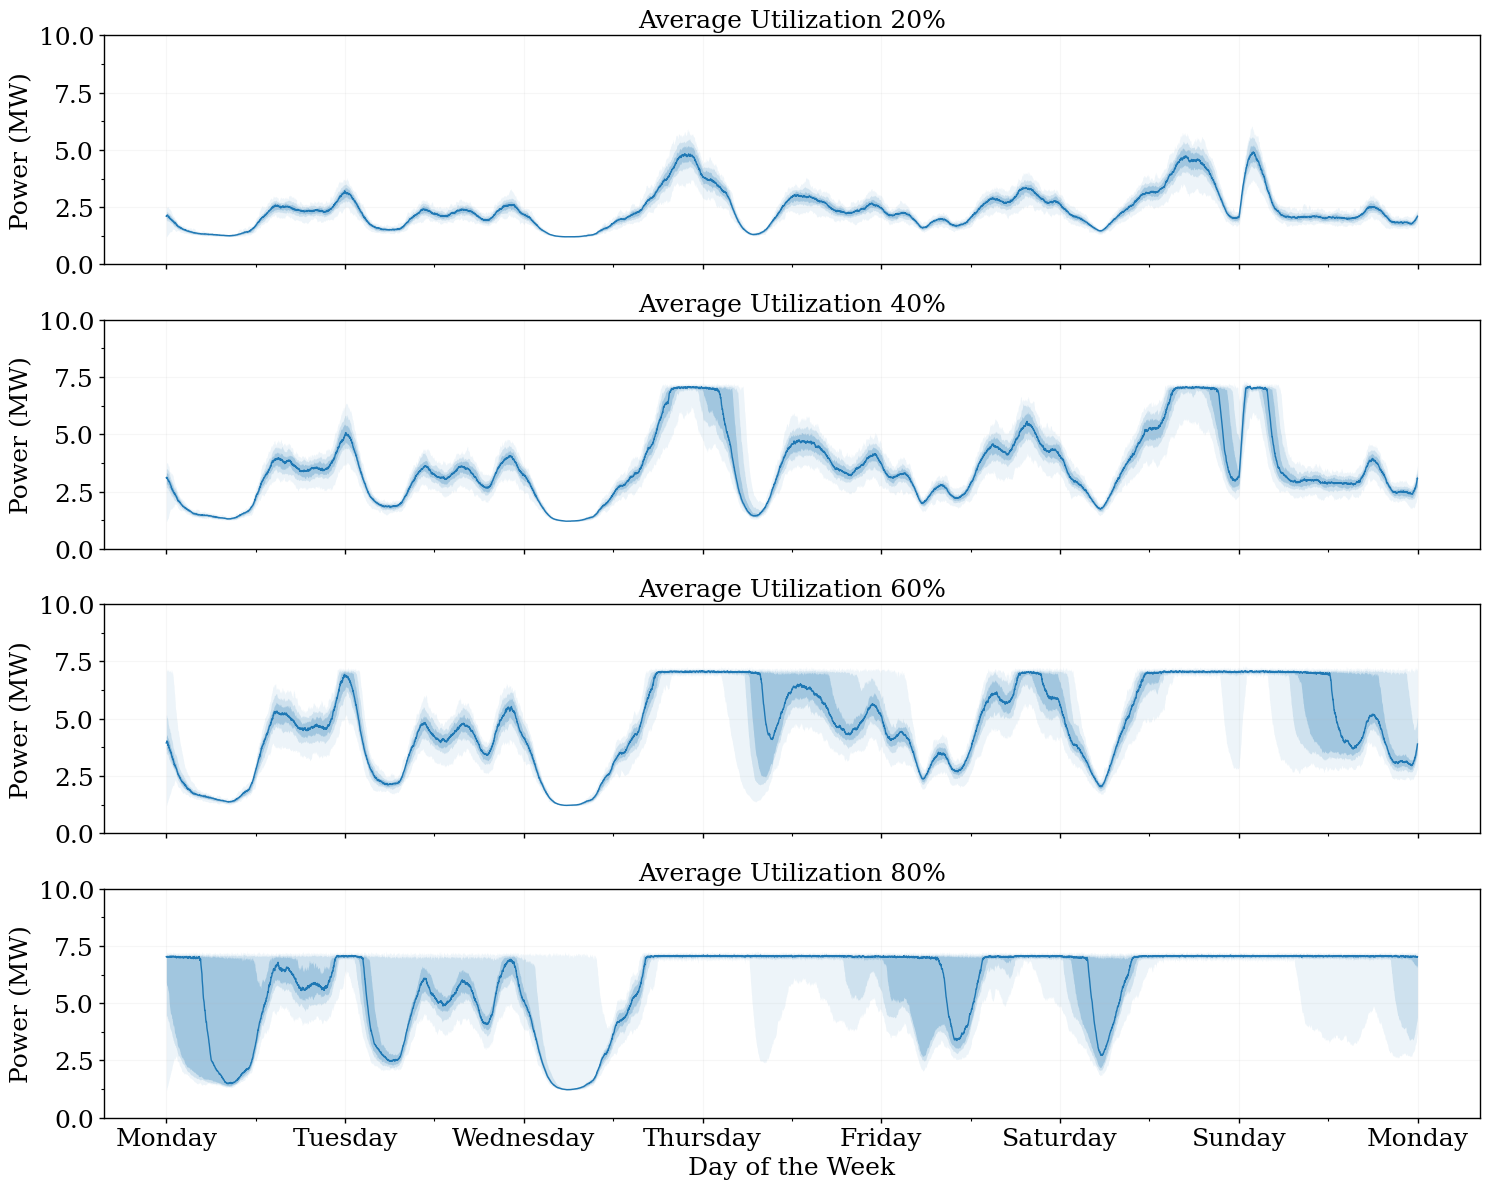

In [10]:
# Plot settings
util_levels = sorted(d_load_by_util.keys())

fig, axes = plt.subplots(
    len(util_levels),
    1,
    sharex=True,
    sharey=True,
    figsize=(l_week, 3 * len(util_levels))
)

# Define bands (lower, upper, alpha, label)
bands = [
    ("p25", "p75", 0.25, "25-75%"),
    ("p10", "p90", 0.15, "10-90%"),
    ("p0", "p100", 0.08, "0-100%"),
]

for ax, util in zip(axes, util_levels):
    df_pct = d_load_by_util[util].copy()
    x = df_pct.index

    # Shade percentile bands
    for low, high, alpha, _label in bands:
        ax.fill_between(
            x,
            df_pct[low] * 1e-6,
            df_pct[high] * 1e-6,
            alpha=alpha,
            linewidth=0,
            color=color
        )

    # Plot median
    ax.plot(x, df_pct["p50"] * 1e-6, linewidth=1,color=color)
    
    ax.set_title(f"Average Utilization {util*100:.0f}%")
    ax.set_ylabel("Power (MW)")
    ax.grid(alpha=0.10)
    _ = ax.set_ylim(ylim)
    ax = set_min_ticks(ax, "y", which="major", num_ticks=4)
    ax = set_min_ticks(ax, "y", which="minor", num_ticks=2)
    
# Common legend (line + patches)
line_handle = mlines.Line2D([], [],
            color=color, linewidth=1, label="50%")
line_handle_minmax = mlines.Line2D([], [],
            color=color, linewidth=1, linestyle="--" , label="min-max")
patch_handles = [
    mpatches.Patch(color=color, alpha=alpha, label=label)
    for _, _, alpha, label in bands
]
handles = [line_handle] + patch_handles

# x-axis ticks and lavels
axes[-1].set_xlabel("Day of the Week")
axes[-1].set_xticks(24*60*np.array([0, 1, 2, 3, 4, 5, 6, 7]))
axes[-1].set_xticklabels(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Monday"])

for ax in axes:
    _ = set_min_ticks(ax, "x", which="minor", num_ticks=2)

plt.tight_layout()

save_figure(
    fig,
    "power-week",
    save_flag,
    1,
    ["png"],     # ["png", "svg", "pdf"]
    full_path=PATH_DATA / "plots"
)

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/03_whole-facility_profiles/colocation/plots/2026-03-30_power-week-legend.png


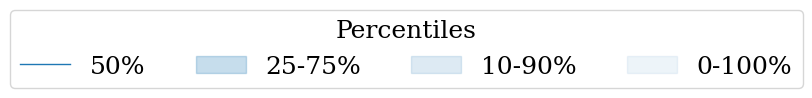

In [11]:
# plot legend
fig_leg, ax_leg = plt.subplots(figsize=(5, 1.0))
ax_leg.legend(
    handles=handles,
    loc="center",
    ncol=len(handles),
    title="Percentiles"
)
ax_leg.axis("off")
fig_leg.tight_layout()

save_figure(
    fig_leg,
    "power-week-legend",
    save_flag,
    1,
    ["png"],     # ["png", "svg", "pdf"]
    full_path=PATH_DATA / "plots"
)